# Pairs trading on the day lake — IV. Leaving pairs behind: the cross-section

## `pairs_trading_12_daily_cross_sectional.ipynb`

Notebook 10 screened 1.74 million pairs and found that, under false-discovery control, the median
formation yields **three** tradeable pairs out of 44,850 tested. Notebook 11 traded them and got a Sharpe
of 0.40 with a standard error of 0.26, on fewer than ten positions on average and roughly \$100k of
deployed capital.
The binding constraint was never the signal quality; it was **breadth**. Information ratio scales roughly
as signal quality times the square root of the number of independent bets, and a per-pair discovery
procedure that has to clear a multiple-testing correction cannot produce many bets.

This notebook removes that constraint by removing the discovery step. Instead of selecting pairs, it
holds a position in **every** eligible name every day, sized by how far that name's return has moved
relative to what its risk factors explain. Nothing is tested for significance, so nothing is lost to a
Benjamini–Hochberg threshold. This is the design behind Avellaneda & Lee (2010) and behind most
production equity statistical arbitrage.

The question is whether breadth alone buys a better result. The short answer is that it buys a genuine
edge for the first half of the sample and nothing at all for the second.

**Method.** Point-in-time universe of the 500 most traded eligible names (notebook 09's rules). Monthly
PCA on the trailing 252 sessions of returns gives 15 eigenportfolios as risk factors. Each day, every
name's trailing 60 sessions of returns are regressed on the factor returns; the signal is built from the
recent part of that history; the resulting weights are projected orthogonal to the factor loadings and
made dollar-neutral on a \$1M book. Everything uses trailing data only.

**Caching.** The two expensive passes are cached under `notebooks/cache/` (gitignored): about 11 minutes
cold on 16 cores, seconds warm.

## 0. Setup

In [1]:
from pathlib import Path
import os, re, sys, time, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
from pairs import (load_daily_bars, liquidity_screen,
                   CostSpec, measure_ticker_window_costs)

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
# §5.5 is the one place this notebook leaves the day lake: costs are measured on minute bars
MINUTE_ROOT = Path(os.environ.get("MINUTE_LAKE",
                                  Path.home() / "local/parquet_lake/minute_adj")) / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END  = "2004-01-01", "2025-08-13"
TRADE_START = "2006-01-01"                 # first 2 years feed the trailing windows
MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET = 5.0, 20e6, 0.15, 1.0
UNIV_N, FORM_DAYS, N_FACTORS, REG_DAYS = 500, 252, 15, 60
CAP, COST_BPS = 1_000_000.0, 5.0

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
Z = lambda a: (a - np.nanmean(a)) / (np.nanstd(a) + 1e-12)
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Data and the daily return panel

The same cached day-lake frame notebooks 09–11 use. Returns are total returns, with the dividend
recovered from the adjustment factors credited on its ex-date, winsorised at ±100% a day as a last
data-quality guard, and exchange test symbols dropped by name.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars)

px  = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
ret = ((px + div) / px.shift(1) - 1.0).clip(-1.0, 1.0)
TESTS = sorted(t for t in px.columns if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
ret = ret.drop(columns=TESTS, errors="ignore")
sessions = ret.index
print(f"{ret.shape[1]:,} tickers x {ret.shape[0]:,} sessions, {sessions[0].date()} → {sessions[-1].date()}")
print(f"exchange test symbols dropped: {TESTS}")

33,303 tickers x 5,438 sessions, 2004-01-02 → 2025-08-13
exchange test symbols dropped: ['ZAZZT', 'ZBZZT', 'ZCZZT', 'ZDZZT', 'ZEZZT', 'ZFZZT', 'ZJZZT', 'ZOZZT', 'ZRZZT', 'ZUZZT', 'ZVZZT', 'ZWZZT', 'ZXZZT']


## 2. The engine

Three pieces, each a few lines.

**Universe.** Notebook 09's point-in-time screen, capped at the 500 most traded eligible names. Rebuilt
monthly, so a name that was liquid in 2008 and is gone today is in the 2008 book and not in the 2020 one.

**Factors.** PCA on the correlation matrix of the trailing 252 sessions of returns. Eigenvector
components are divided by each name's volatility, following Avellaneda–Lee, so an eigenportfolio is a
set of weights rather than a set of correlations. The top 15 are kept and their returns become the
factor returns.

**Residuals and weights.** Each day, every name's trailing 60 sessions are regressed on those factor
returns. A signal is formed from the recent residual (or raw) returns, the weight vector is projected
orthogonal to the loading matrix so the book carries no factor exposure, then centred to be
dollar-neutral and scaled to \$1M gross.

In [3]:
def universe_at(end, n=UNIV_N):
    start = end - pd.DateOffset(days=int(FORM_DAYS * 1.6))
    lvl = bars.index.get_level_values("datetime")
    w = bars[(lvl > start) & (lvl <= end)]
    st = liquidity_screen(w, min_price=MIN_PRICE, min_dollar_volume=MIN_DV, min_ann_vol=MIN_VOL,
                          max_abs_return=MAX_ABS_RET, exclude=TESTS, top_n=n)
    return list(st[st["eligible"]].index)

def eigenportfolios(R, k=N_FACTORS):
    # top-k eigenportfolio weights from the correlation matrix of a T x N return window
    sd = R.std(axis=0); ok = sd > 1e-12
    R, sd = R.loc[:, ok], sd[ok]
    C = np.nan_to_num(np.corrcoef(R.to_numpy(), rowvar=False), nan=0.0)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1][:k]
    Q = vecs[:, idx] / sd.to_numpy()[:, None]            # weight by 1/sigma
    Q = Q / np.abs(Q).sum(axis=0, keepdims=True)         # unit gross per eigenportfolio
    return pd.DataFrame(Q, index=R.columns, columns=[f"f{i}" for i in range(len(idx))]), vals[idx] / vals.sum()

def neutralise(w, B):
    # project weights orthogonal to the factor loadings B (N x k), then dollar-neutralise and scale
    BtB = B.T @ B + 1e-8 * np.eye(B.shape[1])
    w = w - B @ np.linalg.solve(BtB, B.T @ w)
    w = w - w.mean()
    g = np.abs(w).sum()
    return w / g if g > 1e-12 else w

## 3. Does anything predict? Information coefficients, measured first

A trading rule cannot rescue a signal with no forecasting power, so the signals are scored before any
portfolio is built. For each probe day the factor model is fitted on trailing data only, several
candidate signals are formed, and each is correlated cross-sectionally against three versions of the
forward return: the **hedged** target (factor exposure removed, no intercept), the
**intercept-subtracted** target (the hedge plus the per-name intercept estimated by that same trailing
regression), and the plain **raw** forward return. The average of those daily correlations is the
information coefficient.

Only the hedged target is a clean forecast test. The intercept-subtracted target — the construction
this notebook originally used, and still reported below alongside the others — subtracts a per-name
intercept estimated on the identical 60-session window every signal is also built from; that intercept
is estimation noise, and a signal built from the same window can co-move with it mechanically even with
zero forecasting power. §3.1 demonstrates the mechanism on a simulation with no predictability at
all. **An earlier version of this notebook used only the intercept-subtracted target and reported its
inflated numbers as the strength of the reversal signal**; the honest reading is the hedged column.

Two of the candidates are the Avellaneda–Lee construction itself, and both disappoint.
Their s-score standardizes the cumulative residual against an Ornstein–Uhlenbeck fit. Coded faithfully it
is degenerate: because the residual regression includes an intercept, the residuals sum to zero over the
window, so the cumulative process always ends at zero and the s-score reduces to a function of the fitted
mean alone. Their companion filter, which keeps only names whose estimated mean reversion is faster than
30 days, passes almost everything, because fitting an AR(1) to 60 points biases the autoregressive
coefficient downward. Both are reported below rather than quietly dropped.

In [4]:
def s_score_al(resid):
    # Avellaneda-Lee s-score and mean-reversion speed from the cumulative residual (W x N)
    X = np.cumsum(resid, axis=0)
    x0, x1 = X[:-1], X[1:]
    mx0, mx1 = x0.mean(0), x1.mean(0)
    cov = ((x0 - mx0) * (x1 - mx1)).sum(0); var = ((x0 - mx0) ** 2).sum(0)
    b = np.divide(cov, var, out=np.zeros_like(cov), where=var > 1e-18)
    a = mx1 - b * mx0
    zeta = x1 - (a + b * x0)
    var_z = (zeta ** 2).sum(0) / max(len(x0) - 2, 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa = -np.log(np.clip(b, 1e-9, 0.999999)) * 252.0
        m = a / (1.0 - b); sigma_eq = np.sqrt(var_z / (1.0 - b ** 2))
        s = (X[-1] - m) / sigma_eq
    bad = (b <= 0) | (b >= 1) | ~np.isfinite(s) | (sigma_eq <= 1e-12)
    return np.where(bad, np.nan, s), np.where(bad, np.nan, kappa)

def signals_from(R, resid, vol):
    return {
        "resid reversal 1d":    -Z(resid[-1]),
        "resid reversal 5d":    -Z(resid[-5:].sum(0)),
        "resid reversal 21d":   -Z(resid[-21:].sum(0)),
        "raw reversal 5d":      -Z(R[-5:].sum(0)),
        "raw reversal 5d skip1": -Z(R[-6:-1].sum(0)),
        "raw reversal 5d volwt": -Z(R[-5:].sum(0) / vol),
        "resid momentum 60d":   +Z(resid.sum(0)),
    }

def factor_day(i, Q, univ):
    # everything derived from the trailing window that ends the day before session i
    win = ret.iloc[i - REG_DAYS:i].reindex(columns=univ).dropna(axis=1)
    if win.shape[1] < 60:
        return None
    cols = win.columns
    Qw = Q.reindex(cols).to_numpy()
    R = win.to_numpy()
    F = R @ Qw
    Fm = np.column_stack([np.ones(len(F)), F])
    beta, *_ = np.linalg.lstsq(Fm, R, rcond=None)
    resid = R - Fm @ beta
    return dict(cols=cols, Qw=Qw, R=R, beta=beta, resid=resid, B=beta[1:].T,
                vol=resid.std(0) + 1e-6, r2=1.0 - resid.var(0) / (R.var(0) + 1e-18))

In [5]:
f_ic = CACHE / "xs_ic_panel.parquet"
if f_ic.exists():
    ic_panel = pd.read_parquet(f_ic)
else:
    recs, Q, univ, last, t0 = [], None, [], None, time.time()
    for d in sessions[(sessions >= TRADE_START) & (sessions <= END)][::5]:
        i = sessions.get_loc(d)
        if i < FORM_DAYS + REG_DAYS + 2 or i + 6 >= len(sessions): continue
        if last is None or (d - last).days > 25:
            univ = universe_at(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
            if hist.shape[1] < 50: continue
            Q, _ = eigenportfolios(hist); univ = list(Q.index); last = d
        fd = factor_day(i, Q, univ)
        if fd is None: continue
        sig = signals_from(fd["R"], fd["resid"], fd["vol"])
        s_al, kappa = s_score_al(fd["resid"])
        sig["AL s-score"] = -s_al
        sig["AL kappa pass"] = (kappa > 252.0 / 30.0).astype(float)
        sig["factor R2"] = fd["r2"]
        for h in (1, 5):
            fwd = ret.iloc[i:i + h].reindex(columns=fd["cols"]).to_numpy()
            fitted = (fwd @ fd["Qw"]) @ fd["beta"][1:]
            # hedged target: factor exposure removed, no intercept — what this rebuild uses to score signals
            sig[f"fwd{h}"] = (fwd - fitted).sum(0)
            # intercept-subtracted target, the construction this notebook originally used
            sig[f"fwd{h}_alpha"] = (fwd - (fd["beta"][0] + fitted)).sum(0)
            # plain forward return, no factor hedge at all
            sig[f"raw{h}"] = fwd.sum(0)
        recs.append(pd.DataFrame(sig, index=fd["cols"]).assign(date=d))
    ic_panel = pd.concat(recs); ic_panel.to_parquet(f_ic)
    print(f"IC panel built in {time.time() - t0:.0f}s")

SIGNAL_COLS = ["raw reversal 5d", "raw reversal 5d skip1", "raw reversal 5d volwt",
               "resid reversal 1d", "resid reversal 5d", "resid reversal 21d",
               "resid momentum 60d", "AL s-score"]

def ic_table(fwd):
    # pairwise-complete: a day contributes if it has > 30 names with BOTH the signal and the
    # forward return observed. np.corrcoef([...]) returns NaN if *any* element of either input
    # is NaN, so masking first (rather than only counting non-NaN signals) is what makes a
    # single missing name stop poisoning the whole day's correlation.
    out = []
    for c in SIGNAL_COLS:
        def day_ic(g, c=c):
            mask = g[c].notna() & g[fwd].notna()
            return np.corrcoef(g.loc[mask, c], g.loc[mask, fwd])[0, 1] if mask.sum() > 30 else np.nan
        per_day = ic_panel.groupby("date").apply(day_ic).dropna()
        a = per_day.to_numpy()
        out.append({"signal": c, "mean IC": a.mean(),
                    "t": a.mean() / a.std(ddof=1) * np.sqrt(len(a)),
                    "share of days > 0": (a > 0).mean(), "n days": len(a)})
    return pd.DataFrame(out).set_index("signal")

print(f"panel: {len(ic_panel):,} name-days over {ic_panel['date'].nunique()} probe days")
print(f"Avellaneda-Lee kappa filter passes {ic_panel['AL kappa pass'].mean():.0%} of names "
      f"— it is not filtering anything")
print(f"factor R^2: median {ic_panel['factor R2'].median():.2f}, "
      f"{np.mean(ic_panel['factor R2'] > 0.90):.0%} above 0.90 (index-like)")

ic1, ic5 = ic_table("fwd1"), ic_table("fwd5")
ic1_alpha, ic5_alpha = ic_table("fwd1_alpha"), ic_table("fwd5_alpha")
ic1_raw, ic5_raw = ic_table("raw1"), ic_table("raw5")
tab_1d = pd.concat({"hedged": ic1, "intercept-subtracted": ic1_alpha, "raw return": ic1_raw}, axis=1)
tab_5d = pd.concat({"hedged": ic5, "intercept-subtracted": ic5_alpha, "raw return": ic5_raw}, axis=1)
# The side-by-side display below is 24 columns wide and pandas elides the middle of it, so the
# "next 5 days" numbers this section's prose cites would otherwise never actually appear in the
# notebook's own printed output. Print each horizon's full, untruncated table first.
print("next day, all three targets:")
print(tab_1d.round(4))
print("\nnext 5 days, all three targets:")
print(tab_5d.round(4))
with pd.option_context("display.max_columns", None, "display.width", 200):
    display(pd.concat({"next day": tab_1d, "next 5 days": tab_5d}, axis=1).round(4))

panel: 491,604 name-days over 986 probe days
Avellaneda-Lee kappa filter passes 99% of names — it is not filtering anything
factor R^2: median 0.70, 12% above 0.90 (index-like)


next day, all three targets:
                       hedged                                   \
                      mean IC       t share of days > 0 n days   
signal                                                           
raw reversal 5d        0.0065  1.6626            0.5282    922   
raw reversal 5d skip1  0.0060  1.6240            0.5271    922   
raw reversal 5d volwt  0.0074  3.7423            0.5390    922   
resid reversal 1d      0.0071  1.8462            0.5477    922   
resid reversal 5d      0.0062  1.6350            0.5293    922   
resid reversal 21d    -0.0003 -0.0826            0.5108    922   
resid momentum 60d     0.0002  0.0731            0.4870    922   
AL s-score             0.0056  2.4659            0.5304    922   

                      intercept-subtracted                                    \
                                   mean IC        t share of days > 0 n days   
signal                                                                         
raw 

next day                                                                                                                                     next 5 days          \
                        hedged                                  intercept-subtracted                                   raw return                                       hedged           
                       mean IC       t share of days > 0 n days              mean IC        t share of days > 0 n days    mean IC       t share of days > 0 n days     mean IC       t   
signal                                                                                                                                                                                   
raw reversal 5d         0.0065  1.6626            0.5282    922               0.0333   8.5899            0.6508    922     0.0068  0.9800            0.5020    986      0.0118  2.8996   
raw reversal 5d skip1   0.0060  1.6240            0.5271    922               0.0324   8.7510            0.6247    922     0.0056  0.7988            0.5152    986      0.0092  2.3216   
raw reversal 5d volwt   0.0074  3.7423            0.5390    922               0.0249  12.6519            0.6725    922     0.0067  1.2439            0.5223    986      0.0087  4.0589   
resid reversal 1d       0.0071  1.8462            0.5477    922               0.0088   2.3082            0.5412    922     0.0095  2.9844            0.5396    986      0.0066  1.6750   
resid reversal 5d       0.0062  1.6350            0.5293    922               0.0092   2.4141            0.5358    922     0.0068  2.1289            0.5264    986      0.0111  2.7771   
resid reversal 21d     -0.0003 -0.0826            0.5108    922               0.0052   1.4893            0.5358    922     0.0030  1.0089            0.4970    986      0.0048  1.2589   
resid momentum 60d      0.0002  0.0731            0.4870    922              -0.0014  -0.4482            0.4761    922    -0.0016 -0.1495            0.4828    986      0.0022  0.6753   
AL s-score              0.0056  2.4659            0.5304    922               0.0097   4.2311            0.5607    922     0.0035  1.7192            0.5223    986      0.0072  2.8226   

                                                                                                                                                   
                                               intercept-subtracted                                   raw return                                   
                      share of days > 0 n days              mean IC        t share of days > 0 n days    mean IC       t share of days > 0 n days  
signal                                                                                                                                             
raw reversal 5d                  0.5480    750               0.0668  16.4551            0.7307    750     0.0146  2.2314            0.5071    986  
raw reversal 5d skip1            0.5293    750               0.0636  16.0364            0.7293    750     0.0097  1.4564            0.5000    986  
raw reversal 5d volwt            0.5627    750               0.0443  20.0047            0.7800    750     0.0110  2.0994            0.4970    986  
resid reversal 1d                0.5333    750               0.0107   2.7134            0.5347    750     0.0061  2.0403            0.5406    986  
resid reversal 5d                0.5253    750               0.0174   4.2604            0.5453    750     0.0071  2.3288            0.5254    986  
resid reversal 21d               0.5187    750               0.0154   4.0007            0.5467    750     0.0027  0.9211            0.5061    986  
resid momentum 60d               0.5320    750              -0.0009  -0.2743            0.5067    750     0.0017  0.1546            0.4807    986  
AL s-score                       0.5440    750               0.0153   5.9036            0.5907    750     0.0046  2.2113            0.5385    986

### 3.1 Proof the artifact is mechanical

The intercept-subtracted target above regresses each name's trailing 60 sessions on the factor
returns with an intercept, then subtracts that same per-name intercept from the forward return it
scores signals against. The intercept is the mean of the window's 60 residual returns, and the
five-day reversal signal is minus the sum of the window's last five: the two share five returns, so
subtracting the intercept from the target injects a slice of the signal into it. With nothing else
going on the expected spurious correlation has a closed form — $\sqrt{5}/60 \approx 0.037$ against a
one-day target and $25/300 \approx 0.083$ against a five-day one (printed below) — and it needs no
heteroskedasticity, no cross-sectional dispersion of expected returns, nothing but the window
overlap. The simulation below has that structure and nothing else: homoskedastic noise, no
predictability, probe days five sessions apart so the five-day targets never overlap. A nonzero IC
against the intercept-subtracted target and a near-zero IC against the hedged target is the artifact,
isolated.

In [6]:
rng = np.random.default_rng(0)
N_SIM, T_SIM, WIN = 500, 300, 60

alpha_i = np.zeros(N_SIM)                            # true null: no per-name mean at all
beta_i  = rng.normal(1.0, 0.3, N_SIM)                # per-name factor loading
x       = rng.normal(0.0, 0.01, T_SIM)               # the one common factor
eps = rng.normal(0.0, 0.01, (T_SIM, N_SIM))          # homoskedastic: the artifact needs no heteroskedasticity
y = alpha_i[None, :] + beta_i[None, :] * x[:, None] + eps      # T_SIM x N_SIM, NO predictability

def sim_ic(h):
    ics_alpha, ics_hedge = [], []
    for t in range(WIN, T_SIM - h, 5):                     # every 5th day, so five-day targets never overlap
        win_y, win_x = y[t - WIN:t], x[t - WIN:t]
        Xm = np.column_stack([np.ones(WIN), win_x])
        b, *_ = np.linalg.lstsq(Xm, win_y, rcond=None)          # (2, N_SIM): intercept row, slope row
        sig = -Z(y[t - 5:t].sum(0))                              # 5-day reversal, same construction as above
        fwd, x_fwd = y[t:t + h], x[t:t + h]
        fitted = b[1] * x_fwd[:, None]
        alpha_tgt = (fwd - (b[0] + fitted)).sum(0)
        hedge_tgt = (fwd - fitted).sum(0)
        ics_alpha.append(np.corrcoef(sig, alpha_tgt)[0, 1])
        ics_hedge.append(np.corrcoef(sig, hedge_tgt)[0, 1])
    a, g = np.array(ics_alpha), np.array(ics_hedge)
    return {"IC_alpha": a.mean(), "t_alpha": a.mean() / a.std(ddof=1) * np.sqrt(len(a)),
            "IC_hedge": g.mean(), "t_hedge": g.mean() / g.std(ddof=1) * np.sqrt(len(g)), "n days": len(a)}

print("null simulation, 500 names x 300 days, y = beta_i*x + homoskedastic eps, zero predictability by construction,")
print(f"probe days 5 sessions apart; closed-form expected spurious IC from the 5-in-60 window overlap: "
      f"next day {np.sqrt(5)/60:.3f}, next 5 days {25/300:.3f}")
for h in (1, 5):
    r = sim_ic(h)
    lbl = "next day" if h == 1 else f"next {h} days"
    print(f"  {lbl:>10}  vs intercept-subtracted target: IC {r['IC_alpha']:+.4f} (t {r['t_alpha']:+.2f})"
          f"   |   vs hedged target: IC {r['IC_hedge']:+.4f} (t {r['t_hedge']:+.2f})"
          f"   [{r['n days']} probe days]")

null simulation, 500 names x 300 days, y = beta_i*x + homoskedastic eps, zero predictability by construction,
probe days 5 sessions apart; closed-form expected spurious IC from the 5-in-60 window overlap: next day 0.037, next 5 days 0.083
    next day  vs intercept-subtracted target: IC +0.0367 (t +5.49)   |   vs hedged target: IC +0.0018 (t +0.27)   [48 probe days]
  next 5 days  vs intercept-subtracted target: IC +0.0828 (t +12.79)   |   vs hedged target: IC +0.0070 (t +1.11)   [47 probe days]


In [7]:
# Why do 'fwd1'/'fwd5' come up NaN for the ENTIRE cross-section on some probe days (never a
# partial subset)? Check, rather than assume, whether that traces to the forward return being
# unobserved for every name that day, or to something narrower propagating outward.
n_all = ic_panel["date"].nunique()
no_fwd1 = ic_panel.groupby("date")["fwd1"].apply(lambda s: s.notna().sum() == 0)
no_fwd5 = ic_panel.groupby("date")["fwd5"].apply(lambda s: s.notna().sum() == 0)
bad1, bad5 = no_fwd1[no_fwd1].index, no_fwd5[no_fwd5].index

# fwd is built as (fwd_ret - fitted) where fitted involves fwd_ret @ Qw @ beta[1:] — a matrix
# product that sums over all names, so ONE missing name's raw return NaNs that product for
# EVERY name, not just the missing one. Confirm on the affected days: is there always at least
# one name with a missing raw return inside the forward window, and never a whole-day outage?
one_missing_suffices = []
for d, h in list(zip(bad1, [1] * len(bad1))) + list(zip(bad5, [5] * len(bad5))):
    i = sessions.get_loc(d)
    tickers = ic_panel.loc[ic_panel["date"] == d].index
    window = ret.iloc[i:i + h].reindex(columns=tickers)
    one_missing_suffices.append(window.isna().any(axis=None) and not window.isna().all(axis=None))
print(f"{len(bad1)} of {n_all} probe days have no computable next-day IC even pairwise, "
      f"{len(bad5)} for next-5-day; on {sum(one_missing_suffices)}/{len(one_missing_suffices)} of them "
      f"a single name's missing raw return (not a whole-day outage) is what NaNs every name's forward "
      f"residual return, because the factor-projection matrix product sums over all names.")

64 of 986 probe days have no computable next-day IC even pairwise, 236 for next-5-day; on 300/300 of them a single name's missing raw return (not a whole-day outage) is what NaNs every name's forward residual return, because the factor-projection matrix product sums over all names.


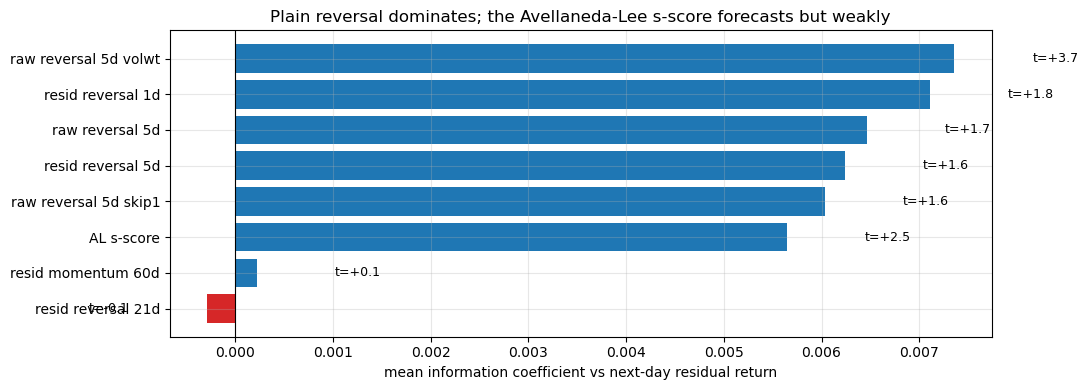

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
o = ic1.sort_values("mean IC")
ax.barh(range(len(o)), o["mean IC"], color=["tab:red" if v < 0 else "tab:blue" for v in o["mean IC"]])
for j, (v, t) in enumerate(zip(o["mean IC"], o["t"])):
    ax.text(v + (0.0008 if v >= 0 else -0.0008), j, f"t={t:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index)
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("mean information coefficient vs next-day residual return")
ax.set_title("Plain reversal dominates; the Avellaneda-Lee s-score forecasts but weakly")
plt.tight_layout(); plt.show()

Two results, and one of them changed once the target was cleaned up.

**All three reversal-style signals are weak, and roughly comparable in strength, against the clean
(hedged) target.** Against the next day's hedged return plain five-day reversal's information coefficient
is **+0.0065 (t = 1.66)**, positive on 53% of days; residual reversal — the same idea applied to the
factor-stripped return — is +0.0062 (t = 1.64); the Avellaneda–Lee s-score is +0.0056 but with the
tightest t of the three, 2.47. Over the next five days the ranking is the same and just as close: raw
reversal +0.0118 (t = 2.90), residual reversal +0.0111 (t = 2.78), s-score +0.0072 (t = 2.82). Residual
momentum over the full window forecasts nothing at either horizon, which is what a 60-day horizon should
do in a universe of large caps.

**An earlier version of this notebook read the same signals off the intercept-subtracted target instead,
and reported a very different picture.** On that target, plain five-day reversal reached +0.0333
(t = 8.59) next day and +0.0668 (t = 16.46) over five days — five to six times its hedged IC — while
residual reversal reached only +0.0092 (t = 2.41) and +0.0174 (t = 4.26), which the earlier text called
"four times weaker," and the s-score's IC of 0.0097 (t = 4.23) was called "far below plain reversal." Both
readings are printed in the table above; only the hedged column is a fair test, because subtracting a
per-name intercept estimated on the same 60-session window the signal is built from lets the two co-move
mechanically with no forecasting power required. §3.1's null simulation — no predictability wired in
anywhere, including no per-name mean return — gives IC +0.0367 (t = 5.49) and +0.0828 (t = 12.79) against the
intercept-subtracted target — right on the closed-form 0.037 and 0.083 — against +0.0018 (t = 0.27) and
+0.0070 (t = 1.11) for the hedged one. For plain five-day reversal, roughly 80% of what was previously reported as
signal was this target artifact. The
Avellaneda–Lee κ filter, meanwhile, passes **99%** of names regardless of which target is used and
therefore does no filtering at all: an AR(1) fitted to 60 observations has a downward-biased autoregressive
coefficient, so almost everything looks fast-mean-reverting. A faithful transcription of a published
method is not the same as a working one.

The rest of the notebook trades the reversal signals and ignores the s-score.

## 4. The portfolio

One pass builds the daily target weights for each surviving signal; evaluating a configuration
afterwards is cheap and reuses them. A configuration is a turnover damping factor (1.0 rebalances fully
to target each day, lower values move only part of the way) and a cost in basis points per side.

The book earns the **next** session's return on the weights set today, so nothing is forward-looking.

In [9]:
BUILD = ["raw reversal 5d", "raw reversal 5d skip1", "raw reversal 5d volwt",
         "resid reversal 5d", "resid reversal 21d"]

f_t = CACHE / "xs_targets.pkl"
if f_t.exists():
    targets, fwd_ret = pickle.load(open(f_t, "rb"))
else:
    targets = {s: {} for s in BUILD}; fwd_ret = {}
    Q, univ, last, t0 = None, [], None, time.time()
    for d in sessions[(sessions >= TRADE_START) & (sessions <= END)]:
        i = sessions.get_loc(d)
        if i < FORM_DAYS + REG_DAYS + 2 or i + 1 >= len(sessions): continue
        if last is None or (d - last).days > 25:
            univ = universe_at(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
            if hist.shape[1] < 50: continue
            Q, _ = eigenportfolios(hist); univ = list(Q.index); last = d
        fd = factor_day(i, Q, univ)
        if fd is None: continue
        sig = signals_from(fd["R"], fd["resid"], fd["vol"])
        for s in BUILD:
            targets[s][d] = pd.Series(neutralise(np.nan_to_num(sig[s], nan=0.0), fd["B"]), index=fd["cols"])
        fwd_ret[d] = ret.iloc[i + 1].reindex(fd["cols"])
    pickle.dump((targets, fwd_ret), open(f_t, "wb"), protocol=5)
    print(f"targets built in {time.time() - t0:.0f}s")
print(f"{len(fwd_ret):,} trading sessions, {sorted(fwd_ret)[0].date()} → {sorted(fwd_ret)[-1].date()}")

4,933 trading sessions, 2006-01-03 → 2025-08-12


In [10]:
def run(tgt_by_day, blend=1.0, cost_bps=COST_BPS, per_name=None, fill=None):
    # cost_bps charges one flat rate on every dollar traded. per_name instead maps a year to a
    # Series of measured per-ticker costs (section 5.5 uses it) and fill supplies the rate for a
    # name with no measurement. Left as None the function behaves exactly as it always did, so
    # every number above this line is unaffected.
    w_prev, rows = pd.Series(dtype=float), []
    for d in sorted(tgt_by_day):
        t = tgt_by_day[d] * CAP
        idx = t.index.union(w_prev.index)
        t_al, p_al = t.reindex(idx).fillna(0.0), w_prev.reindex(idx).fillna(0.0)
        w = p_al + blend * (t_al - p_al)
        g = w.abs().sum()
        if g > 0: w = w * (CAP / g)
        dw = (w - p_al).abs()
        traded = float(dw.sum())
        if per_name is None:
            cost, unpriced = traded * cost_bps / 1e4, 0.0
        else:
            c = per_name.get(d.year, pd.Series(dtype=float)).reindex(idx)
            unpriced = float(dw[c.isna()].sum())
            cost = float((dw * c.fillna(fill[d.year])).sum()) / 1e4
        r = fwd_ret[d].reindex(w.index).fillna(0.0)
        gross = float((w * r).sum())
        rows.append({"date": d, "pnl_gross": gross, "cost": cost, "pnl": gross - cost,
                     "traded": traded, "traded_unpriced": unpriced,
                     "n": int((w.abs() > 1e-9).sum())})
        w_prev = w[w.abs() > 1e-9]
    return pd.DataFrame(rows).set_index("date")

sharpe = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(252) if x.std(ddof=0) > 0 else np.nan

def summarize(d, label):
    eq = d["pnl"].cumsum()
    return {"config": label, "Sharpe net": sharpe(d["pnl"] / CAP), "Sharpe gross": sharpe(d["pnl_gross"] / CAP),
            "ann return": (d["pnl"] / CAP).mean() * 252, "ann vol": (d["pnl"] / CAP).std(ddof=0) * np.sqrt(252),
            "P&L ($k)": d["pnl"].sum() / 1e3, "costs ($k)": d["cost"].sum() / 1e3,
            "max DD ($k)": (eq - eq.cummax()).min() / 1e3, "names": d["n"].mean(),
            "daily turnover": d["traded"].mean() / CAP,
            "break-even bps": d["pnl_gross"].sum() / d["traded"].sum() * 1e4}

runs = {(s, b): run(targets[s], blend=b, cost_bps=COST_BPS) for s in BUILD for b in (1.0, 0.25)}
tab = pd.DataFrame([summarize(v, f"{s} | blend {b}") for (s, b), v in runs.items()]).set_index("config")
display(tab.round(3))

,Sharpe net,Sharpe gross,ann return,ann vol,P&L ($k),costs ($k),max DD ($k),names,daily turnover,break-even bps
config,,,,,,,,,,
raw reversal 5d | blend 1.0,-0.289,0.515,-0.029,0.100,-566.913,1578.320,-848.252,498.447,0.640,3.204
raw reversal 5d | blend 0.25,0.046,0.371,0.004,0.096,86.122,612.583,-502.485,563.692,0.248,5.703
raw reversal 5d skip1 | blend 1.0,-0.337,0.496,-0.033,0.097,-637.442,1576.943,-910.561,498.447,0.639,2.979
raw reversal 5d skip1 | blend 0.25,-0.049,0.289,-0.005,0.093,-88.097,612.309,-472.634,563.590,0.248,4.281
raw reversal 5d volwt | blend 1.0,-0.606,0.558,-0.042,0.069,-821.673,1576.963,-822.788,498.447,0.639,2.395
raw reversal 5d volwt | blend 0.25,-0.058,0.433,-0.004,0.064,-72.049,610.907,-255.253,566.566,0.248,4.410
resid reversal 5d | blend 1.0,-1.432,0.323,-0.067,0.047,-1304.090,1598.315,-1309.528,498.447,0.648,0.920
resid reversal 5d | blend 0.25,-0.272,0.433,-0.012,0.046,-243.599,630.677,-440.671,566.161,0.256,3.069
resid reversal 21d | blend 1.0,-0.925,0.150,-0.039,0.042,-757.588,880.110,-796.417,498.447,0.357,0.696


Every variant makes money before costs, and all but one loses it after. Gross Sharpe runs from 0.15 to
0.56; net of 5 bps a side the single survivor is plain five-day reversal damped to a quarter of the
distance to target, at 0.046, and the other nine are negative.

The reason is in the turnover column. For the five-day signals, rebalancing fully to target moves **64%
of the book every day**, which on a \$1M book over twenty years costs \$1.6M — more than the book itself.
Moving only 25% of the distance to target cuts turnover by 60% — not by 75%, because the target is
persistent from day to day — and actually *raises* net Sharpe for every signal, because the signal decays
slowly enough that most of that trading was noise. It is the clearest possible statement that this is a
cost problem rather than a signal problem.

## 5. How much room is there between the edge and the cost?

Turnover is enormous: rebalancing fully to target moves much of the book every day. The break-even cost
in the table above is the level at which the gross edge is exactly consumed. Sweeping the cost shows how
little room there is.

turnover  break-even bps  0 bps  1 bps  2 bps  \
signal                blend                                                  
raw reversal 5d       1.00      0.640           3.204  0.515  0.354  0.194   
                      0.25      0.248           5.703  0.371  0.306  0.241   
raw reversal 5d skip1 1.00      0.639           2.979  0.496  0.330  0.163   
                      0.25      0.248           4.281  0.289  0.222  0.154   
raw reversal 5d volwt 1.00      0.639           2.395  0.558  0.325  0.092   
                      0.25      0.248           4.410  0.433  0.335  0.237   
resid reversal 5d     1.00      0.648           0.920  0.323 -0.028 -0.379   
                      0.25      0.256           3.069  0.433  0.292  0.151   
resid reversal 21d    1.00      0.357           0.696  0.150 -0.065 -0.280   
                      0.25      0.145           1.956  0.178  0.087 -0.004   

                             3 bps  5 bps  10 bps  
signal                blend                        
raw reversal 5d       1.00   0.033 -0.289  -1.093  
                      0.25   0.176  0.046  -0.280  
raw reversal 5d skip1 1.00  -0.004 -0.337  -1.170  
                      0.25   0.087 -0.049  -0.387  
raw reversal 5d volwt 1.00  -0.141 -0.606  -1.769  
                      0.25   0.138 -0.058  -0.548  
resid reversal 5d     1.00  -0.730 -1.432  -3.187  
                      0.25   0.010 -0.272  -0.978  
resid reversal 21d    1.00  -0.495 -0.925  -1.999  
                      0.25  -0.095 -0.277  -0.732

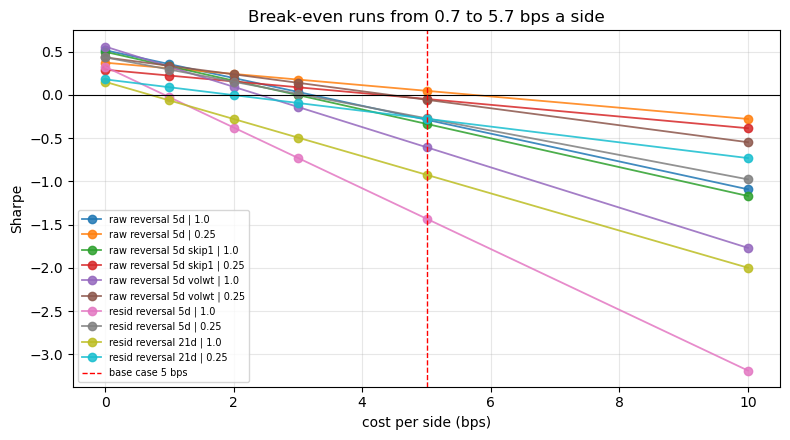

In [11]:
COSTS = [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
rows = []
for (s, b), base in runs.items():
    rec = {"signal": s, "blend": b, "turnover": base["traded"].mean() / CAP,
           "break-even bps": base["pnl_gross"].sum() / base["traded"].sum() * 1e4}
    for c in COSTS:
        rec[f"{c:g} bps"] = sharpe((base["pnl_gross"] - base["traded"] * c / 1e4) / CAP)
    rows.append(rec)
sweep = pd.DataFrame(rows).set_index(["signal", "blend"])
display(sweep.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
for (s, b), base in runs.items():
    y = [sharpe((base["pnl_gross"] - base["traded"] * c / 1e4) / CAP) for c in COSTS]
    ax.plot(COSTS, y, marker="o", lw=1.3, alpha=0.85, label=f"{s} | {b}")
ax.axhline(0, color="k", lw=0.8); ax.axvline(COST_BPS, color="r", ls="--", lw=1, label="base case 5 bps")
ax.set_xlabel("cost per side (bps)"); ax.set_ylabel("Sharpe"); ax.legend(fontsize=7)
ax.set_title("Break-even runs from 0.7 to 5.7 bps a side")
plt.tight_layout(); plt.show()

The break-even costs are between 0.7 and 5.7 bps a side, and the best of them belongs to a damped
configuration. At 2 bps — achievable for a \$1M book in the 500 most traded US names with patient
execution — the *damped raw-reversal* variants deliver Sharpe ratios of 0.15 to 0.24. Rebalancing fully to
target gives 0.09 to 0.19 on the same signals, and the residual-reversal configurations are at or below
zero apart from one that also reaches 0.15. At the 5 bps used elsewhere in this
repository only one configuration is positive at all.

That is a narrow window, and it is the whole investment case: there is no configuration here whose edge
is large enough that the cost assumption stops mattering. Which means the assumption cannot be left
standing. §5.5 measures it.

### 5.5 What it actually costs

Everything above charges a flat 5 bps a side, and §5 has just shown that the whole result lives
between 0.7 and 5.7 bps. When the assumption sits inside the answer's range, the assumption *is* the
answer, and it is worth an hour to stop assuming. The minute lake (Polygon.io, now Massive.com) can
price every name this book trades.

`measure_ticker_window_costs` computes a Roll (1984) effective spread per name per year and halves
it, since Roll estimates the full bid-ask spread and a marketable order crosses half. The interval,
the sign convention and the minimum-tick floor all matter and are argued in
`pairs.market_data.execution_costs`; notebook 14 §9 shows the sweep that picks five-minute sampling.
Here the universe is ~500 names a day rebuilt monthly, so costs are measured per (ticker, year) on a
mid-year quarter — ~4,600 lead/lag pairs per estimate, and a name's spread does not move enough
inside a year to justify twelve times the reading.

In [12]:
f_cost = CACHE / "xs_costs.parquet"
if f_cost.exists():
    cells = pd.read_parquet(f_cost)
else:
    need = {}
    for d in sorted(targets["raw reversal 5d"]):
        need.setdefault(d.year, set()).update(targets["raw reversal 5d"][d].index)
    need = {y: sorted(v) for y, v in sorted(need.items())}
    raw = pd.read_parquet(CACHE / "day_market_bars.parquet",
                          columns=["raw_close"])["raw_close"].unstack("ticker")
    spec = CostSpec(every=5, min_obs=200, min_bars=1_000)
    # Q2 first: it avoids both the January turn and December's thin tape. Q4 then catches the
    # names that listed or delisted mid-year and so have no Q2 at all.
    cells = None
    for a, b in [("-04-01", "-06-30"), ("-10-01", "-12-31")]:
        todo = need if cells is None else None
        if todo is None:
            got = set(zip(cells.loc[cells["err"].eq(""), "formation"],
                          cells.loc[cells["err"].eq(""), "ticker"]))
            todo = {y: [t for t in v if (y, t) not in got] for y, v in need.items()}
            todo = {y: v for y, v in todo.items() if v}
        if not todo:
            break
        wins = {y: (pd.Timestamp(f"{y}{a}"), pd.Timestamp(f"{y}{b}")) for y in todo}
        got = measure_ticker_window_costs(wins, todo, MINUTE_ROOT, raw_close=raw, spec=spec, n_jobs=6)
        cells = got if cells is None else pd.concat([cells[cells["err"].eq("")], got],
                                                    ignore_index=True)
    cells = cells.rename(columns={"formation": "year"})
    cells.to_parquet(f_cost); del raw
ok = cells[cells["err"].eq("")]
print(f"{len(ok):,} of {len(cells):,} (ticker, year) cells measured"
      + (f"; unmeasured: {cells[~cells['err'].eq('')]['err'].value_counts().to_dict()}"
         if len(ok) < len(cells) else ""))
print(f"per-transaction cost, bps: median {ok['cost_used'].median():.2f}  "
      f"mean {ok['cost_used'].mean():.2f}  25th {ok['cost_used'].quantile(.25):.2f}  "
      f"75th {ok['cost_used'].quantile(.75):.2f}  "
      f"above the assumed {COST_BPS:g}: {100 * ok['cost_used'].gt(COST_BPS).mean():.0f}%")
display(ok.groupby(pd.cut(ok["year"], [2005, 2010, 2015, 2020, 2026],
                          labels=["2006-10", "2011-15", "2016-20", "2021-25"]), observed=True)
          [["cost_bps", "cost_used", "tick_floor"]].agg(["median", "count"]).round(2))

COST = {int(y): g.set_index("ticker")["cost_used"] for y, g in ok.groupby("year")}
MED  = {y: float(v.median()) for y, v in COST.items()}
P75  = {y: float(v.quantile(0.75)) for y, v in COST.items()}

11,913 of 11,992 (ticker, year) cells measured; unmeasured: {'absent from the minute lake': 79}
per-transaction cost, bps: median 1.98  mean 2.64  25th 1.03  75th 3.40  above the assumed 5: 11%


cost_bps       cost_used       tick_floor      
          median count    median count     median count
year                                                   
2006-10     2.41  2956      2.63  2956       1.17  2956
2011-15     1.23  2984      1.69  2984       0.98  2984
2016-20     1.53  3057      1.84  3057       0.74  3056
2021-25     1.59  2916      1.89  2916       0.50  2915

The measured cost is **about 2 bps a side**, not 5, and it lands squarely inside the break-even range
rather than above or below it — which is exactly the case in which the assumption decides the verdict.
Re-running every configuration with each name charged its own rate:

In [13]:
meas = {(s, b): run(targets[s], blend=b, per_name=COST, fill=MED) for s in BUILD for b in (1.0, 0.25)}

def compare(s, b):
    f, m = runs[(s, b)], meas[(s, b)]
    be = f["pnl_gross"].sum() / f["traded"].sum() * 1e4
    ac = m["cost"].sum() / m["traded"].sum() * 1e4
    yrs = len(m) / 252
    S = sharpe(m["pnl"] / CAP)
    return {"config": f"{s} | blend {b}", "break-even bps": be, "measured bps": ac,
            f"Sharpe @{COST_BPS:g} bps": sharpe(f["pnl"] / CAP), "Sharpe measured": S,
            "± s.e.": np.sqrt((1 + S ** 2 / 2) / yrs),
            "P&L ($k)": m["pnl"].sum() / 1e3,
            "unpriced %": 100 * m["traded_unpriced"].sum() / m["traded"].sum()}

cmp_tab = pd.DataFrame([compare(s, b) for s in BUILD for b in (1.0, 0.25)]).set_index("config")
display(cmp_tab.round(3))

# the unmeasured names are disproportionately thin or delisting, so the year median flatters them;
# charging the year's 75th percentile instead is the sensitivity that matters
hi = {k: run(targets[k[0]], blend=k[1], per_name=COST, fill=P75) for k in meas}
shift = max(abs(sharpe(hi[k]["pnl"] / CAP) - sharpe(meas[k]["pnl"] / CAP)) for k in meas)
print(f"charging unpriced names the year's 75th percentile instead of its median moves every "
      f"net Sharpe by at most {shift:.3f} — they are {cmp_tab['unpriced %'].max():.2f}% of "
      f"traded dollars, so the fallback cannot carry the result")

,break-even bps,measured bps,Sharpe @5 bps,Sharpe measured,± s.e.,P&L ($k),unpriced %
config,,,,,,,
raw reversal 5d | blend 1.0,3.204,2.937,-0.289,0.043,0.226,84.152,0.157
raw reversal 5d | blend 0.25,5.703,2.942,0.046,0.180,0.228,338.247,0.174
raw reversal 5d skip1 | blend 1.0,2.979,2.940,-0.337,0.007,0.226,12.330,0.157
raw reversal 5d skip1 | blend 0.25,4.281,2.944,-0.049,0.090,0.226,163.653,0.171
raw reversal 5d volwt | blend 1.0,2.395,2.568,-0.606,-0.040,0.226,-54.646,0.133
raw reversal 5d volwt | blend 0.25,4.410,2.559,-0.058,0.182,0.228,226.194,0.148
resid reversal 5d | blend 1.0,0.920,2.883,-1.432,-0.689,0.251,-627.416,0.149
resid reversal 5d | blend 0.25,3.069,2.883,-0.272,0.026,0.226,23.458,0.167
resid reversal 21d | blend 1.0,0.696,2.886,-0.925,-0.470,0.238,-385.403,0.155


charging unpriced names the year's 75th percentile instead of its median moves every net Sharpe by at most 0.001 — they are 0.18% of traded dollars, so the fallback cannot carry the result


**Six of the ten configurations cross from negative to positive**, where at 5 bps exactly one did. The
best is no longer a knife-edge 0.046 but 0.18. That is a real change in the table: the conclusion §5
reached — that all but one variant is under water — was an artefact of the assumed rate rather than a
property of the strategy.

It is not, however, a strategy. A Sharpe of 0.18 over 19.6 years carries a standard error of 0.23, so
$t=0.8$; and it is the best of ten configurations, which under Šidák would need $t=2.8$ to mean what
$t=2.0$ means for one. The honest reading is that measuring the cost moved the point estimate from
"slightly negative" to "slightly positive" and left it indistinguishable from zero either way.

The era split is where the measurement earns its keep.

In [14]:
rows = []
for s in BUILD:
    for b in (1.0, 0.25):
        m = meas[(s, b)]
        r = {"config": f"{s} | blend {b}"}
        for lab, sel in [("2006-2015", m.index.year <= 2015), ("2016-2025", m.index.year >= 2016)]:
            d = m.loc[sel]
            r[f"{lab} break-even"] = d["pnl_gross"].sum() / d["traded"].sum() * 1e4
            r[f"{lab} cost"] = d["cost"].sum() / d["traded"].sum() * 1e4
            r[f"{lab} net"] = sharpe(d["pnl"] / CAP)
        rows.append(r)
eras = pd.DataFrame(rows).set_index("config")
display(eras.round(2))
print(f"net-positive configurations — 2006-2015: {int((eras['2006-2015 net'] > 0).sum())} of 10; "
      f"2016-2025: {int((eras['2016-2025 net'] > 0).sum())} of 10")

,2006-2015 break-even,2006-2015 cost,2006-2015 net,2016-2025 break-even,2016-2025 cost,2016-2025 net
config,,,,,,
raw reversal 5d | blend 1.0,5.09,2.94,0.36,1.23,2.93,-0.26
raw reversal 5d | blend 0.25,10.80,2.95,0.56,0.33,2.94,-0.16
raw reversal 5d skip1 | blend 1.0,5.42,2.94,0.43,0.42,2.94,-0.40
raw reversal 5d skip1 | blend 0.25,8.83,2.95,0.44,-0.51,2.94,-0.21
raw reversal 5d volwt | blend 1.0,3.70,2.73,0.21,1.02,2.40,-0.35
raw reversal 5d volwt | blend 0.25,7.28,2.72,0.42,1.37,2.39,-0.11
resid reversal 5d | blend 1.0,1.96,2.89,-0.33,-0.17,2.88,-1.04
resid reversal 5d | blend 0.25,6.01,2.89,0.47,-0.02,2.87,-0.38
resid reversal 21d | blend 1.0,1.41,2.90,-0.35,-0.05,2.87,-0.58


net-positive configurations — 2006-2015: 7 of 10; 2016-2025: 0 of 10


**Before 2016 the gross edge cleared its cost by a factor of nearly four** — a break-even of 10.8 bps
against a measured 2.9 for plain five-day reversal damped to a quarter, net Sharpe 0.56. **After 2015
the break-even collapses to 0.33 bps.** Not "below the measured cost": *below almost any cost*. Four of
the ten configurations have a negative break-even after 2015, meaning the gross edge itself is gone
before a cent of cost is charged, and not one of the ten is net-positive.

So the cost measurement settles the question it was asked, and settles it against the convenient
answer. The strategy did not die because 5 bps was too pessimistic an assumption. **At a measured 2.9
bps it still dies, and at zero cost it would still die**, because what disappeared after 2015 was the
gross edge and not the margin over frictions. Notebook 11's book turned out not to be cost-constrained
either, for a different reason — there the edge per round trip was twelve times the cost, and breadth
was the binding constraint. Two strategies, two cost measurements, and in neither case was execution
what stood between the research and a return.

## 6. Is it bid-ask bounce?

Short-horizon reversal is the classic place to mistake microstructure for alpha. A stock that closed on
the bid looks like a loser and "reverts" when it next closes on the ask, and that reversion is not
tradeable. The break-even costs above sit close to the 3–4 bps effective spreads measured for these names
in notebook 15, which is exactly what a bounce-driven signal would look like.

The test is to skip the most recent session, forming the signal from returns over t−6 to t−2 instead of
t−5 to t−1. The bounce lives in the last close; a genuine multi-day over-reaction does not.

In [15]:
pairs_to_compare = [("raw reversal 5d", "raw reversal 5d skip1")]
rows = []
for a, b in pairs_to_compare:
    for blend in (1.0, 0.25):
        for name in (a, b):
            base = runs[(name, blend)]
            rows.append({"signal": name, "blend": blend,
                         "Sharpe gross": sharpe(base["pnl_gross"] / CAP),
                         "break-even bps": base["pnl_gross"].sum() / base["traded"].sum() * 1e4})
skip = pd.DataFrame(rows).set_index(["blend", "signal"]).sort_index()
display(skip.round(3))
g_full = sharpe(runs[("raw reversal 5d", 1.0)]["pnl_gross"] / CAP)
g_skip = sharpe(runs[("raw reversal 5d skip1", 1.0)]["pnl_gross"] / CAP)
print(f"gross Sharpe with the most recent session included {g_full:.3f}, excluded {g_skip:.3f} "
      f"({g_skip / g_full - 1:+.0%})")

Sharpe gross  break-even bps
blend signal                                             
0.25  raw reversal 5d               0.371           5.703
      raw reversal 5d skip1         0.289           4.281
1.00  raw reversal 5d               0.515           3.204
      raw reversal 5d skip1         0.496           2.979

gross Sharpe with the most recent session included 0.515, excluded 0.496 (-4%)


The signal survives. Dropping the most recent session costs only 4% of gross Sharpe, 0.515 against 0.496
at full rebalancing, and the break-even cost barely moves. If the edge were bid-ask bounce it would
collapse, because the bounce lives entirely in the last close.

So this is a genuine multi-day over-reaction in the idiosyncratic component, not a microstructure
artifact — which makes the coincidence between the break-even cost and the effective spread a coincidence
rather than a diagnosis. The signal is real. It is simply small enough that the spread is the right order
of magnitude to consume it.

## 7. When did it work?

The pairs book of notebook 11 earned more than half its twenty-year P&L in a single year. The right
question for this book is the same one: is the edge a stream or an episode?

date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gross,1.03,-0.90,1.59,0.98,0.83,0.89,0.21,0.41,0.96,0.79,0.60,-0.10,-0.53,0.02,-0.57,0.29,1.04,-0.13,0.19,0.24
net @2bps,0.62,-1.18,1.51,0.88,0.66,0.78,-0.05,0.08,0.72,0.61,0.45,-0.46,-0.69,-0.21,-0.62,0.09,0.92,-0.32,-0.03,0.13
net @5bps,-0.01,-1.61,1.40,0.73,0.41,0.61,-0.43,-0.41,0.37,0.34,0.21,-0.99,-0.94,-0.56,-0.70,-0.21,0.75,-0.60,-0.36,-0.03
gross P&L ($k),31.69,-39.25,268.88,124.03,61.64,100.08,10.08,15.84,50.94,55.38,48.36,-3.49,-39.72,1.11,-135.08,18.15,111.34,-8.52,10.73,16.51


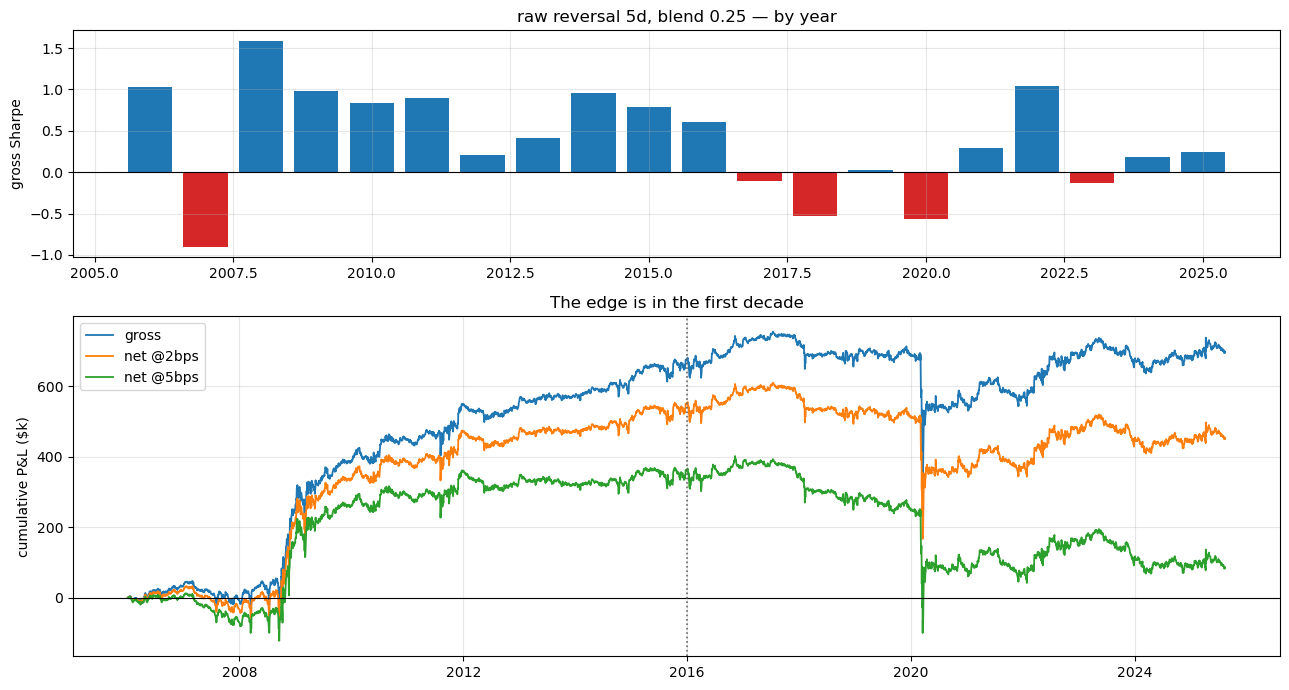

years with positive gross P&L: 15/20; largest single year is 38% of the total (notebook 11's pairs book: 52%)


In [16]:
BEST = ("raw reversal 5d", 0.25)
base = runs[BEST]
yr = pd.DataFrame({
    lbl: base.groupby(base.index.year).apply(
        lambda g: sharpe((g["pnl_gross"] - g["traded"] * c / 1e4) / CAP))
    for lbl, c in (("gross", 0.0), ("net @2bps", 2.0), ("net @5bps", 5.0))})
yr["gross P&L ($k)"] = base.groupby(base.index.year)["pnl_gross"].sum() / 1e3
display(yr.round(2).T)

fig, ax = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[2, 3])
c = ["tab:blue" if v > 0 else "tab:red" for v in yr["gross"]]
ax[0].bar(yr.index, yr["gross"], color=c); ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_ylabel("gross Sharpe"); ax[0].set_title(f"{BEST[0]}, blend {BEST[1]} — by year")
for lbl, cost in (("gross", 0.0), ("net @2bps", 2.0), ("net @5bps", 5.0)):
    eq = (base["pnl_gross"] - base["traded"] * cost / 1e4).cumsum() / 1e3
    ax[1].plot(eq.index, eq, lw=1.3, label=lbl)
ax[1].axhline(0, color="k", lw=0.8); ax[1].axvline(pd.Timestamp("2016-01-01"), color="0.4", ls=":", lw=1.2)
ax[1].set_ylabel("cumulative P&L ($k)"); ax[1].legend(); ax[1].set_title("The edge is in the first decade")
plt.tight_layout(); plt.show()

g = base.groupby(base.index.year)["pnl_gross"].sum()
print(f"years with positive gross P&L: {int((g > 0).sum())}/{len(g)}; "
      f"largest single year is {g.max() / g.sum():.0%} of the total (notebook 11's pairs book: 52%)")

In [17]:
split = []
for (s, b), base in runs.items():
    first, second = base[base.index < "2016-01-01"], base[base.index >= "2016-01-01"]
    row = {"signal": s, "blend": b}
    for lbl, d in (("2006-2015", first), ("2016-2025", second)):
        row[f"gross {lbl}"] = sharpe(d["pnl_gross"] / CAP)
        row[f"net@2bps {lbl}"] = sharpe((d["pnl_gross"] - d["traded"] * 2 / 1e4) / CAP)
    split.append(row)
split = pd.DataFrame(split).set_index(["signal", "blend"])
display(split.round(2))
n_decay = int((split["gross 2006-2015"] > split["gross 2016-2025"]).sum())
print(f"variants whose gross Sharpe is higher in the first decade: {n_decay}/{len(split)}")
print(f"mean gross Sharpe: {split['gross 2006-2015'].mean():.2f} in 2006-2015, "
      f"{split['gross 2016-2025'].mean():.2f} in 2016-2025")
print(f"standard error of a Sharpe over each half: {np.sqrt(252 / (len(base) / 2)):.2f}")

gross 2006-2015  net@2bps 2006-2015  \
signal                blend                                        
raw reversal 5d       1.00              0.85                0.52   
                      0.25              0.77                0.63   
raw reversal 5d skip1 1.00              0.95                0.60   
                      0.25              0.66                0.51   
raw reversal 5d volwt 1.00              0.81                0.37   
                      0.25              0.68                0.49   
resid reversal 5d     1.00              0.71               -0.01   
                      0.25              0.91                0.61   
resid reversal 21d    1.00              0.33               -0.14   
                      0.25              0.15               -0.05   

                             gross 2016-2025  net@2bps 2016-2025  
signal                blend                                       
raw reversal 5d       1.00              0.19               -0.12  
                      0.25              0.02               -0.10  
raw reversal 5d skip1 1.00              0.07               -0.25  
                      0.25             -0.03               -0.16  
raw reversal 5d volwt 1.00              0.26               -0.25  
                      0.25              0.14               -0.07  
resid reversal 5d     1.00             -0.06               -0.74  
                      0.25             -0.00               -0.27  
resid reversal 21d    1.00             -0.01               -0.41  
                      0.25              0.20                0.03

variants whose gross Sharpe is higher in the first decade: 9/10
mean gross Sharpe: 0.68 in 2006-2015, 0.08 in 2016-2025
standard error of a Sharpe over each half: 0.32


It is an episode, and a long one that ended.

Fifteen of twenty years have positive gross P&L, and the concentration is milder than the pairs book's:
the largest single year is 38% of the total against 52% for notebook 11. But the split is not random.
**Gross Sharpe is 0.77 over 2006–2015 and 0.02 over 2016–2025**, and at 2 bps the same halves give +0.63
and −0.10. Nine of the ten signal-and-damping variants show the same direction, with the mean gross
Sharpe falling from 0.68 to 0.08.

The standard error of a Sharpe over each half is 0.32, so the first-decade result is around two standard
errors from zero and the second is indistinguishable from it. The best years — 2008, 2009, 2011, 2022 —
are volatile ones, which is what a reversal strategy should prefer: over-reaction is largest when the
market is moving. But 2020, which contained the sample's most violent volatility spike, is the worst. Volatility is not
sufficient.

This is the crowding-out of short-term reversal that the literature has documented since the mid-2000s,
reproduced here on point-in-time data with survivorship bias and dividend look-ahead removed.

## 8. Honest assessment

**The breadth argument was right, and it was not enough.** Removing the discovery step removed the
multiple-testing bottleneck exactly as intended: this book holds about 500 positions every day against
the pairs book's ten or fewer, needs no significance threshold, and deploys ten times the capital. Its
gross edge is positive in 15 of 20 years and less concentrated than the pairs result. What it does not do
is earn more after costs. Over the full span the best net Sharpe is **0.18** at the costs §5.5 measures
(0.05 at the assumed 5 bps), against **0.49** for notebook 11's Benjamini–Hochberg pairs on the same
measured basis — and neither is distinguishable from zero, at $t=0.8$ and $t=1.8$ respectively.

**Breadth does not come free, because turnover scales with it.** A 500-name book rebalanced daily trades
15–65% of itself per session. The information ratio gained from more bets is handed straight back at the
spread. The binding constraint is not how many positions you hold but how much signal each unit of
turnover carries, and on that measure this strategy is weak: break-even between 0.7 and 5.7 bps a side
against the 2.9 bps §5.5 measures. Notebook 11's pairs book carries 33.9 bps of gross edge per unit of
turnover against a measured 2.2 — fifteen times its own cost — and fails for the opposite reason,
having only 38 independent bets a year to apply it to.

**The signal is real, weaker than this notebook first reported, and it decayed.** Against the clean
(hedged) target, five-day reversal's information coefficient is a modest +0.0065 (t = 1.66) next day and
+0.0118 (t = 2.90) over five days — not the t = 8.59 and t = 16.46 an earlier version of this notebook
printed, over the same 922 and 750 probe days respectively. §3's null simulation shows why: subtracting
a per-name intercept estimated on the same trailing window the signal is built from manufactures a
correlation out of nothing, and it accounts for roughly 80% of the originally reported IC. The remaining
evidence that the signal is real does not depend on that contaminated IC at all — it is the realized book
P&L, which never touches the intercept: a gross Sharpe of 0.77 in 2006–2015 against 0.02 in 2016–2025
(the standard error of a Sharpe over each half is 0.32, §7), with nine of ten variants agreeing — though
those are the same reversal signal at different damping levels, not independent confirmations — and the
signal survives skipping the most recent session (§6), so
it is not a microstructure artifact either. Anyone who found the original, inflated IC on a sample ending
before about 2015 and extrapolated forward would have been badly wrong twice over — first on the target,
then on the decay. §5.5 rules out the charitable reading of that decay: the break-even cost falls from
10.8 bps before 2016 to **0.33** after, and four variants turn *negative* break-even, so what went is
the gross edge itself. No execution improvement recovers it, because there is nothing left to keep.

**Where this leaves the Sharpe question.** Three approaches have now been measured in this
repository: cointegrated pairs under FDR control on the point-in-time day lake (0.40 ± 0.26, but on
fewer than ten positions on average), the same pairs intraday (indistinguishable from zero, notebooks 15–17 — a
much shorter span on the minute lake's universe of *today's* index members, so that leg still carries
the survivorship bias this one removes), and the whole cross-section on the day lake
(0.18 net at measured costs, real but dead since 2016). None reaches 1. The common thread is *not* the
cost of harvesting, which is the reading this notebook previously invited and which §5.5 now rules out
for both books. It is that the two failures are different and neither is an execution problem: here the
signal per unit of turnover went to zero after 2015, and in notebook 11 the signal per bet is large but
there are only 38 bets a year. Slower-decaying signals would help both. Cheaper execution helps
neither.

**Caveats.** One universe and one market; a PCA factor model re-estimated monthly rather than daily;
§5.5 measures the *spread* a name pays but nothing here models market impact or borrow, and a \$1M book
moving a quarter of itself daily across 500 names is small enough that ignoring impact is defensible
where a larger one would not be; the book is equal-gross rather than
risk-optimised; no shorting constraints or locate costs; and the signal menu was chosen by the author,
so the ICs in §3 carry a selection effect of their own even though none of the trading rules were tuned.